In [2]:
%pip -q install open_clip_torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.4 MB/s eta 0:00:00


In [3]:
import gc
import json
import random
import hashlib
import shutil
import subprocess
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision

from PIL import Image, ImageDraw
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from torchvision.models import resnet50, vit_b_16, ResNet50_Weights, ViT_B_16_Weights
from torch.utils.data import Dataset, DataLoader
from google.colab import drive
from IPython.display import display
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import open_clip

#! Seed, runtime and existing project directories
SEED = 6304
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

drive.mount("/content/drive")
TASK_ROOT = Path("/content/drive/MyDrive/pa1-beyond-iid/task1")
DATA_PATH = TASK_ROOT / "data/stl10_labeled.npz"
FEATURE_DIR = TASK_ROOT / "results/features"
HEAD_DIR = TASK_ROOT / "models/heads"
BASELINE_DIR = TASK_ROOT / "results/clean_baseline"
CUE_DIR = TASK_ROOT / "results/shape_texture"
IMAGE_DIR = CUE_DIR / "images"
SHEET_DIR = CUE_DIR / "review_sheets"
WEIGHT_DIR = TASK_ROOT / "models/adain"
for path in (CUE_DIR, IMAGE_DIR, SHEET_DIR, WEIGHT_DIR):
    path.mkdir(parents=True, exist_ok=True)

MODEL_NAMES = ["resnet50", "vit_b16", "clip_b32"]
MODEL_ORDER = MODEL_NAMES + ["clip_zero_shot"]
FEATURE_DIMS = {"resnet50": 2048, "vit_b16": 768, "clip_b32": 512}

#! Fixed choices: five disjoint pairs, two directions, 40 candidates per direction
CLASS_PAIRS = [
    ("airplane", "cat"),
    ("bird", "truck"),
    ("car", "deer"),
    ("dog", "ship"),
    ("horse", "monkey")
]
CANDIDATES_PER_DIRECTION = 40
MIN_VALID_PER_DIRECTION = 20
STYLE_STRENGTH = 0.75  #! AdaIN alpha; choose before reviewing or evaluating
REJECTION_RULE = (
    "Inspect content / style / stylized image at usable resolution before evaluation. "
    "Accept only if the content object's silhouette remains recognizable and the donor "
    "style supplies visible local texture or appearance. Reject if the content disappears, "
    "the style donor object dominates the output, the texture transfer is imperceptible, "
    "or severe artifacts/clipping make either cue uninterpretable. "
    "Decisions must not depend on any classifier prediction."
)

#! Load same original 500 test images, labels and IDs from Part A
with np.load(DATA_PATH, allow_pickle=False) as data:
    test_images = data["test_images"]
    test_labels = data["test_labels"].astype(np.int64)
    test_indices = data["test_indices"].astype(np.int64)
    CLASS_NAMES = data["class_names"].tolist()

clean_ids = np.load(BASELINE_DIR / "clean_image_ids.npy", allow_pickle=False)
if (len(test_images) != 500 or not np.array_equal(clean_ids, test_indices)
    or sorted(sum(([a, b] for a, b in CLASS_PAIRS), [])) != sorted(CLASS_NAMES)):
    raise ValueError("Dataset, clean image IDs, or chosen class pairs do not match Part A/C.")

needed = ([HEAD_DIR / f"{name}_head.pt" for name in MODEL_NAMES]
          + [BASELINE_DIR / f"{name}_clean_predictions.npz" for name in MODEL_ORDER]
          + [FEATURE_DIR / "clip_zeroshot.pt"])
missing = [str(path) for path in needed if not path.is_file()]
if missing:
    raise FileNotFoundError(f"Missing Part B/C files: {missing}")

#! Lock pre-evaluation choices; prevent an accidental change during reruns
config = {
    "experiment": "Task 1 Part E - Shape vs Texture", "seed": SEED,
    "dataset": "STL-10 official test subset", "class_names": CLASS_NAMES,
    "test_ids_file": str(BASELINE_DIR / "clean_image_ids.npy"),
    "class_pairs": [list(pair) for pair in CLASS_PAIRS],
    "candidates_per_direction": CANDIDATES_PER_DIRECTION,
    "min_valid_per_direction": MIN_VALID_PER_DIRECTION,
    "style_strength_alpha": STYLE_STRENGTH,
    "rejection_rule": REJECTION_RULE,
    "hypothesis": "Cue conflicts may elicit content, texture, or other decisions; no architectural ranking assumed.",
    "primary_metrics": ["shape_texture_other_counts", "shape_bias_pct", "coverage_pct"],
    "source_implementation": "https://github.com/naoto0804/pytorch-AdaIN",
    "weights_release": "https://github.com/naoto0804/pytorch-AdaIN/releases/tag/v0.0.0",
    "preprocessing": "PIL RGB bicubic resize to 224x224 BEFORE AdaIN and model normalization"
}
config_path = CUE_DIR / "experiment_config.json"
if config_path.is_file():
    if json.loads(config_path.read_text()) != config:
        raise ValueError("Existing experimental configuration differs; do not overwrite it.")
else:
    config_path.write_text(json.dumps(config, indent=2))

print("Device:", DEVICE)
print("Five class pairs:", CLASS_PAIRS)
print("Candidates planned:", len(CLASS_PAIRS) * 2 * CANDIDATES_PER_DIRECTION)
print("Minimum valid conflicts:", len(CLASS_PAIRS) * 2 * MIN_VALID_PER_DIRECTION)
print("Results:", CUE_DIR)


Mounted at /content/drive
Device: cuda
Five class pairs: [('airplane', 'cat'), ('bird', 'truck'), ('car', 'deer'), ('dog', 'ship'), ('horse', 'monkey')]
Candidates planned: 400
Minimum valid conflicts: 200
Results: /content/drive/MyDrive/pa1-beyond-iid/task1/results/shape_texture


In [4]:
#! Clone a public implementation; never change pretrained weights during the experiment
ADAIN_REPO = Path("/content/pytorch-AdaIN")
if not (ADAIN_REPO / "net.py").is_file():
    subprocess.run(
        ["git", "clone", "--depth", "1", "https://github.com/naoto0804/pytorch-AdaIN.git", str(ADAIN_REPO)],
        check=True
    )
source_commit = subprocess.check_output(
    ["git", "-C", str(ADAIN_REPO), "rev-parse", "HEAD"], text=True
).strip()

#! Preserve checkpoints on Google Drive for future runs
weight_urls = {
    "vgg_normalised.pth": "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/vgg_normalised.pth",
    "decoder.pth": "https://github.com/naoto0804/pytorch-AdaIN/releases/download/v0.0.0/decoder.pth"
}
for filename, url in weight_urls.items():
    destination = WEIGHT_DIR / filename
    if not destination.is_file():
        temp_path = destination.with_suffix(".download")
        try:
            urllib.request.urlretrieve(url, str(temp_path))
            if temp_path.stat().st_size < 1_000_000:
                raise RuntimeError(f"Downloaded checkpoint is unexpectedly small: {filename}")
            temp_path.replace(destination)
        finally:
            temp_path.unlink(missing_ok=True)
    print("AdaIN checkpoint:", filename, "bytes:", destination.stat().st_size)

#! Only import the inspected repository after the files are available
import sys
sys.path.insert(0, str(ADAIN_REPO))
import net as adain_net
from function import adaptive_instance_normalization

vgg_full = adain_net.vgg
adain_decoder = adain_net.decoder
vgg_full.load_state_dict(torch.load(WEIGHT_DIR / "vgg_normalised.pth", map_location="cpu", weights_only=True))
adain_decoder.load_state_dict(torch.load(WEIGHT_DIR / "decoder.pth", map_location="cpu", weights_only=True))
adain_encoder = nn.Sequential(*list(vgg_full.children())[:31]).to(DEVICE).eval()
adain_decoder = adain_decoder.to(DEVICE).eval()
for net in (adain_encoder, adain_decoder):
    for parameter in net.parameters():
        parameter.requires_grad = False

#! Record exact external source and weights used
weight_hashes = {}
for filename in weight_urls:
    digest = hashlib.sha256()
    with (WEIGHT_DIR / filename).open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    weight_hashes[filename] = digest.hexdigest()

source_info = {"source_url": config["source_implementation"], "source_commit": source_commit,
               "weights_sha256": weight_hashes}
source_path = CUE_DIR / "adain_source.json"
if source_path.exists() and json.loads(source_path.read_text()) != source_info:
    raise ValueError("AdaIN source/weights differ from this experiment's previous run.")
source_path.write_text(json.dumps(source_info, indent=2))
print("AdaIN encoder and decoder loaded in evaluation mode.")
print("Source commit:", source_commit)


AdaIN checkpoint: vgg_normalised.pth bytes: 80102481
AdaIN checkpoint: decoder.pth bytes: 14023458
AdaIN encoder and decoder loaded in evaluation mode.
Source commit: 47950d0e6656a95a80a4b105c4c0f58d38ef785c


## Cell 3 — Freeze a balanced, deterministic content/style pairing manifest
All donors are **from the same 500 selected STL-10 images**. Each unordered class pair is sampled in both directions; source and donor have distinct classes. Manifest rows are fixed before stylization or evaluation. Each row stores the original content ID, donor ID, labels, and output filename; do not regenerate a different pairing just because later predictions are unexpected.

In [5]:
#! Reconstruct one fixed manifest, and refuse to silently replace an existing plan
rng = np.random.default_rng(SEED)
name_to_label = {name: i for i, name in enumerate(CLASS_NAMES)}
rows = []

for pair_id, (class_a, class_b) in enumerate(CLASS_PAIRS):
    for direction, (content_class, style_class) in enumerate(((class_a, class_b), (class_b, class_a))):
        content_label = name_to_label[content_class]
        style_label = name_to_label[style_class]
        content_pool = np.flatnonzero(test_labels == content_label)
        style_pool = np.flatnonzero(test_labels == style_label)
        if min(len(content_pool), len(style_pool)) < CANDIDATES_PER_DIRECTION:
            raise ValueError("Not enough images in one class for the predeclared candidate count.")

        content_positions = rng.choice(content_pool, CANDIDATES_PER_DIRECTION, replace=False)
        style_positions = rng.choice(style_pool, CANDIDATES_PER_DIRECTION, replace=False)
        for j, (content_pos, style_pos) in enumerate(zip(content_positions, style_positions)):
            candidate_id = f"p{pair_id:02d}_d{direction}_{j:03d}"
            rows.append({
                "candidate_id": candidate_id, "pair": f"{class_a}__{class_b}",
                "direction": f"{content_class}_to_{style_class}",
                "content_class": content_class, "style_class": style_class,
                "content_label": int(content_label), "style_label": int(style_label),
                "content_pos": int(content_pos), "style_pos": int(style_pos),
                "content_id": int(test_indices[content_pos]), "style_id": int(test_indices[style_pos]),
                "image_file": f"images/{candidate_id}.png"
            })

planned = pd.DataFrame(rows)
manifest_path = CUE_DIR / "candidate_manifest.csv"
if manifest_path.exists():
    old = pd.read_csv(manifest_path)
    pd.testing.assert_frame_equal(old, planned, check_dtype=False)
else:
    planned.to_csv(manifest_path, index=False)

print("Frozen candidates:", len(planned))
display(planned.groupby(["pair", "direction"]).size().rename("planned").reset_index())


Frozen candidates: 400


,pair,direction,planned
0,airplane__cat,airplane_to_cat,40
1,airplane__cat,cat_to_airplane,40
2,bird__truck,bird_to_truck,40
3,bird__truck,truck_to_bird,40
4,car__deer,car_to_deer,40
5,car__deer,deer_to_car,40
6,dog__ship,dog_to_ship,40
7,dog__ship,ship_to_dog,40
8,horse__monkey,horse_to_monkey,40
9,horse__monkey,monkey_to_horse,40


## Cell 4 — Generate candidate cue-conflict images (resumable)
Resize the **content and style** images independently to the common 224×224 RGB image using the same bicubic preprocessing as Part B. Encode both with the pretrained AdaIN encoder, transfer per-channel feature statistics, interpolate with the fixed `alpha`, decode, and save each output as a lossless PNG. Existing valid images are reused. Stylization is **not** yet considered a valid cue conflict until your visual review.

In [6]:
COMMON_RESIZE = transforms.Resize((224, 224), interpolation=InterpolationMode.BICUBIC)
TO_TENSOR = transforms.ToTensor()
TO_PIL = transforms.ToPILImage()
STYLE_BATCH_SIZE = 8


def canonical_image(position):
    rgb = np.transpose(test_images[int(position)], (1, 2, 0))
    return COMMON_RESIZE(Image.fromarray(rgb).convert("RGB"))


@torch.inference_mode()
def stylize_batch(content_batch, style_batch, strength):
    content_features = adain_encoder(content_batch)
    style_features = adain_encoder(style_batch)
    transferred = adaptive_instance_normalization(content_features, style_features)
    mixed = strength * transferred + (1.0 - strength) * content_features
    return adain_decoder(mixed).clamp(0.0, 1.0)


#! Generate only missing images; atomic saves avoid a partially written PNG
pending = []
for row in planned.itertuples(index=False):
    output_path = CUE_DIR / row.image_file
    if output_path.is_file():
        try:
            with Image.open(output_path) as check:
                if check.size != (224, 224) or check.mode != "RGB":
                    raise ValueError(f"Invalid cached image: {output_path}")
                check.verify()
        except Exception as exc:
            raise ValueError(f"Damaged existing PNG; inspect before replacing: {output_path}") from exc
    else:
        pending.append(row)

print("Existing candidates:", len(planned) - len(pending), "| To generate:", len(pending))
for start in tqdm(range(0, len(pending), STYLE_BATCH_SIZE), desc="AdaIN candidate generation"):
    subset = pending[start:start + STYLE_BATCH_SIZE]
    content = torch.stack([TO_TENSOR(canonical_image(row.content_pos)) for row in subset]).to(DEVICE)
    style = torch.stack([TO_TENSOR(canonical_image(row.style_pos)) for row in subset]).to(DEVICE)
    result = stylize_batch(content, style, STYLE_STRENGTH).cpu()

    for item, row in zip(result, subset):
        output_path = CUE_DIR / row.image_file
        temp_path = output_path.with_suffix(".tmp.png")
        TO_PIL(item).convert("RGB").save(temp_path, format="PNG")
        temp_path.replace(output_path)

    del content, style, result

print("Candidate images generated:", sum((CUE_DIR / f).is_file() for f in planned.image_file))
#! Free AdaIN GPU memory before later feature extraction
adain_encoder.cpu()
adain_decoder.cpu()
del adain_encoder, adain_decoder, vgg_full
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()


Existing candidates: 400 | To generate: 0


AdaIN candidate generation: 0it [00:00, ?it/s]

Candidate images generated: 400


## Cell 5 — Generate review contact sheets and a decision template **before prediction**
Open all ten contact sheets from Google Drive; each row of each triplet shows **original content | style donor | stylized output** and its candidate ID. Zoom into full-size individual PNGs when necessary. The first run creates `review_decisions.csv` with empty `decision` cells. **You must personally inspect and fill all 400 rows:** `accept` or `reject`. For rejects, enter a short `reason` (e.g., `content_unrecognizable`, `texture_absent`, `style_object_dominates`, `severe_artifacts`). Save the edited CSV **in the same folder** before running Cell 6. No model prediction is used in selection.

Review sheet: airplane__cat__airplane_to_cat.png
Review sheet: airplane__cat__cat_to_airplane.png
Review sheet: bird__truck__bird_to_truck.png
Review sheet: bird__truck__truck_to_bird.png
Review sheet: car__deer__car_to_deer.png
Review sheet: car__deer__deer_to_car.png
Review sheet: dog__ship__dog_to_ship.png
Review sheet: dog__ship__ship_to_dog.png
Review sheet: horse__monkey__horse_to_monkey.png
Review sheet: horse__monkey__monkey_to_horse.png
Preserved existing human review: /content/drive/MyDrive/pa1-beyond-iid/task1/results/shape_texture/review_decisions.csv
Inspect all 10 review sheets and save manual decisions before Cell 6.


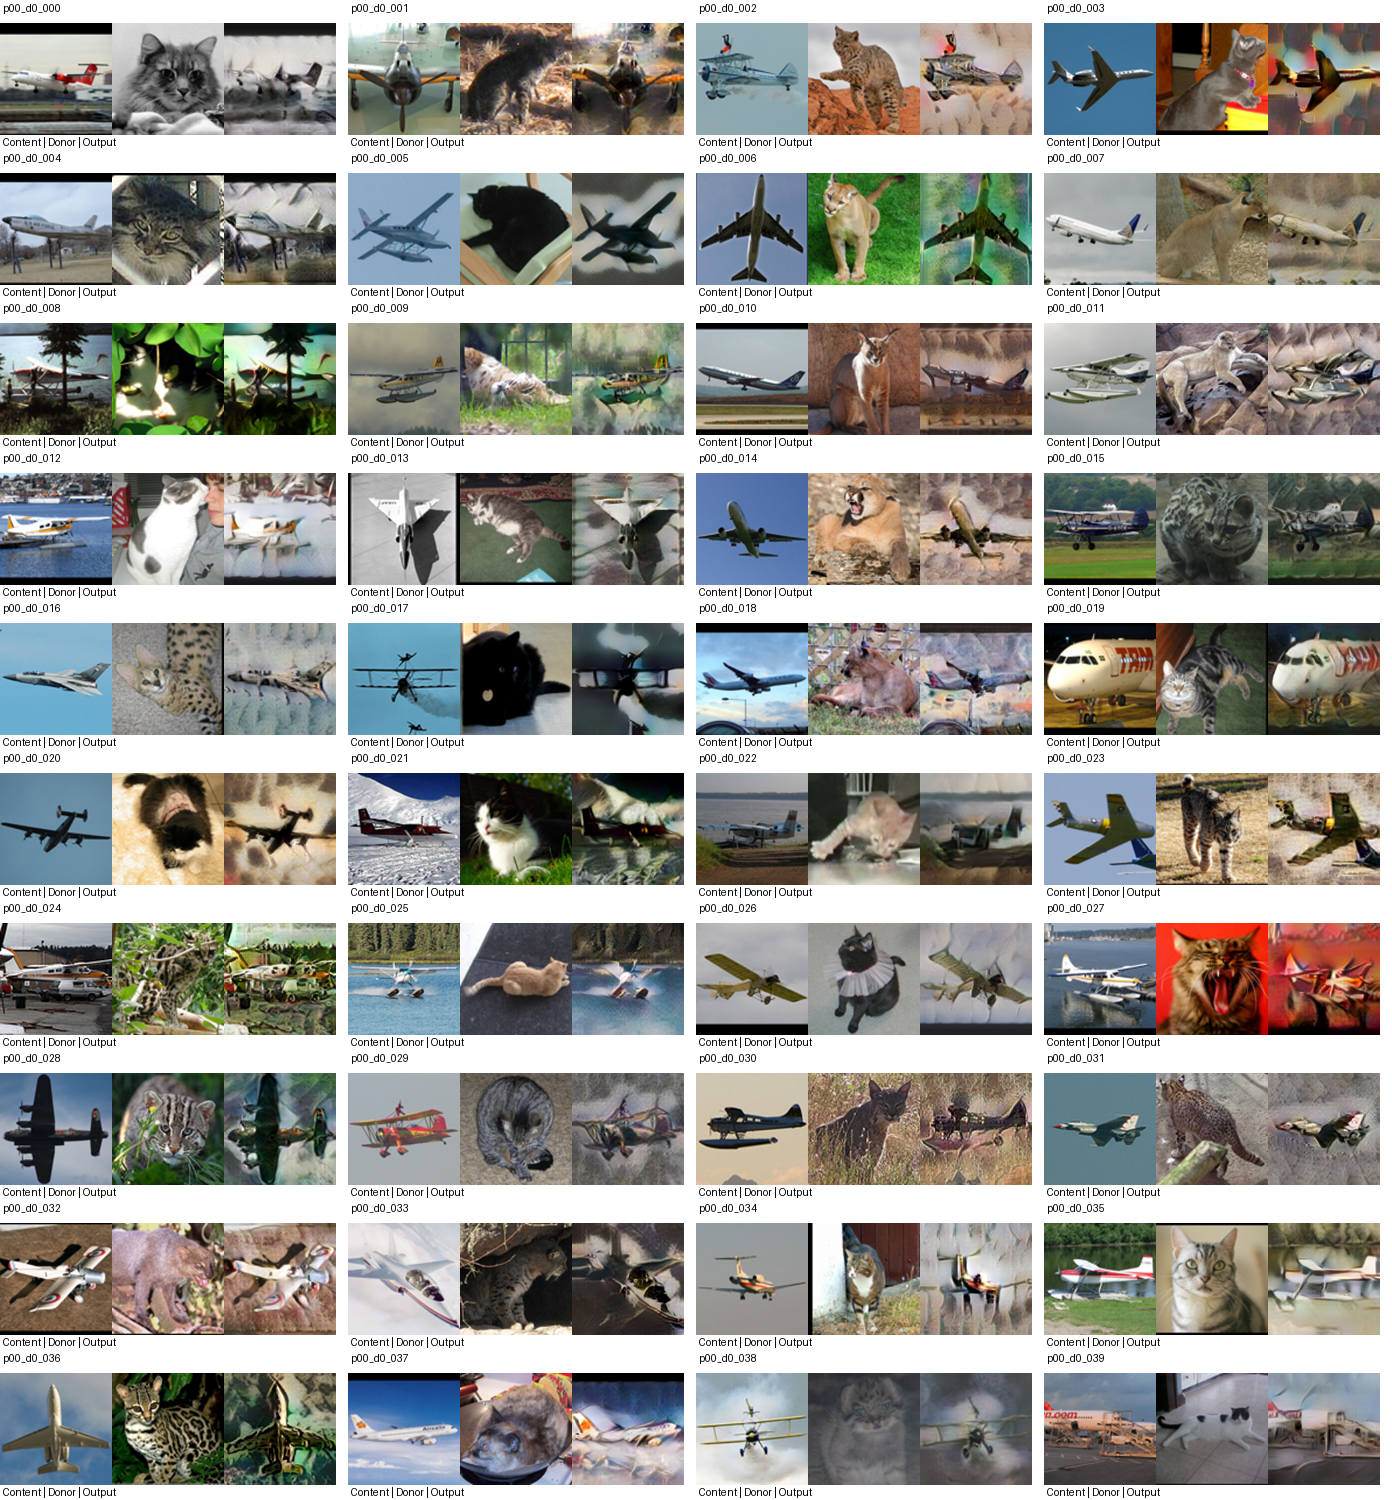

In [7]:
#! Build legible contact sheets; labels and images are fixed by the manifest
THUMB_SIZE = 112
SHEET_COLUMNS = 4
PANEL_W, PANEL_H = 3 * THUMB_SIZE + 12, THUMB_SIZE + 38

for (pair, direction), subset in planned.groupby(["pair", "direction"], sort=True):
    subset = subset.sort_values("candidate_id")
    n_rows = int(np.ceil(len(subset) / SHEET_COLUMNS))
    sheet = Image.new("RGB", (PANEL_W * SHEET_COLUMNS, PANEL_H * n_rows), "white")
    draw = ImageDraw.Draw(sheet)

    for k, row in enumerate(subset.itertuples(index=False)):
        x = (k % SHEET_COLUMNS) * PANEL_W
        y = (k // SHEET_COLUMNS) * PANEL_H
        images = (canonical_image(row.content_pos), canonical_image(row.style_pos),
                  Image.open(CUE_DIR / row.image_file).convert("RGB"))
        for p, image in enumerate(images):
            sheet.paste(image.resize((THUMB_SIZE, THUMB_SIZE)),
                        (x + p * THUMB_SIZE, y + 23))
        draw.text((x + 3, y + 2), row.candidate_id, fill="black")
        draw.text((x + 3, y + THUMB_SIZE + 24), "Content | Donor | Output", fill="black")

    sheet_path = SHEET_DIR / f"{pair}__{direction}.png"
    sheet.save(sheet_path)
    print("Review sheet:", sheet_path.name)

#! Only create the review CSV once: don't wipe previous human decisions
review_path = CUE_DIR / "review_decisions.csv"
if not review_path.exists():
    pd.DataFrame({"candidate_id": planned.candidate_id,
                  "decision": [""] * len(planned),
                  "reason": [""] * len(planned)}).to_csv(review_path, index=False)
    print("NEW review template:", review_path)
else:
    print("Preserved existing human review:", review_path)

print("Inspect all 10 review sheets and save manual decisions before Cell 6.")
display(Image.open(sorted(SHEET_DIR.glob("*.png"))[0]))


In [8]:
#! Zip all generated images for visual review

import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/shape_texture_images",
    "zip",
    root_dir=IMAGE_DIR
)

files.download(zip_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cell 6 — Validate and freeze your **human** rejection decisions
**Stop here to review the images.** The code deliberately refuses to advance with missing decisions or unreasoned rejections. It records counts for both accepted and rejected candidates and chooses an equal number of valid conflicts per pair/direction (at least 20 each). Selection uses **only human decisions and candidate IDs**, never predictions. A frozen review hash and balanced selected manifest prevent later reruns from silently changing the experiment.

In [9]:
review = pd.read_csv(review_path, keep_default_na=False)

if (len(review) != len(planned) or review.candidate_id.duplicated().any()
    or set(review.candidate_id) != set(planned.candidate_id)):
    raise ValueError("Review CSV must contain exactly one entry for each of the 400 candidate IDs.")

review["decision"] = review["decision"].astype(str).str.strip().str.lower()
review["reason"] = review["reason"].astype(str).str.strip()

if not review.decision.isin(["accept", "reject", "needs_review"]).all():
    raise ValueError("Allowed decisions: accept, reject, needs_review.")

if ((review.decision == "reject") & (review.reason == "")).any():
    raise ValueError("Rejected candidates need a visual reason.")

#! Freeze decisions, and keep uncertain images separate from genuine rejections
review = review.sort_values("candidate_id").reset_index(drop=True)

review_frozen_path = CUE_DIR / "review_frozen.csv"

if review_frozen_path.is_file():
    pd.testing.assert_frame_equal(
        pd.read_csv(review_frozen_path, keep_default_na=False), review, check_dtype=False
    )
else:
    review.to_csv(review_frozen_path, index=False)

review_sha256 = hashlib.sha256(review_frozen_path.read_bytes()).hexdigest()

reviewed = planned.merge(review, on="candidate_id", validate="one_to_one")

counts = (reviewed.groupby(["pair", "direction", "decision"])
          .size().rename("count").reset_index())

counts.to_csv(CUE_DIR / "accept_reject_counts.csv", index=False)
display(counts)

#! Select an equal 20 accepted images in each direction by fixed candidate ID
accepted = reviewed.loc[reviewed.decision == "accept"].copy()
accepted_counts = accepted.groupby(["pair", "direction"]).size()

if len(accepted_counts) != 10 or accepted_counts.min() < MIN_VALID_PER_DIRECTION:
    raise RuntimeError(
        "Fewer than 20 accepted images in one or more directions: "
        f"{accepted_counts.to_dict()}. Resolve uncertain images before evaluation."
    )

per_direction = MIN_VALID_PER_DIRECTION
selected = (accepted.sort_values("candidate_id")
            .groupby(["pair", "direction"], sort=True)
            .head(per_direction).sort_values("candidate_id")
            .reset_index(drop=True))

selected["review_sha256"] = review_sha256
selected_path = CUE_DIR / "selected_manifest.csv"

if selected_path.exists():
    pd.testing.assert_frame_equal(
        pd.read_csv(selected_path, keep_default_na=False), selected, check_dtype=False
    )
else:
    selected.to_csv(selected_path, index=False)

#! Disclose review provenance; do not misrepresent this as a user's manual inspection
provenance = {
    "review_type": "AI-assisted visual review before model evaluation",
    "visual_sources": "400 original generated PNGs at 224x224 and 10 paired contact sheets; content/donor thumbnails 112x112",
    "review_rule": REJECTION_RULE,
    "classifier_predictions_used": False,
    "limitation": "Ambiguous candidates kept as needs_review, not counted as rejected. Donor fine texture not always resolvable from contact sheets."
}
provenance_path = CUE_DIR / "review_provenance.json"

if provenance_path.exists() and json.loads(provenance_path.read_text()) != provenance:
    raise ValueError("Review provenance differs from existing saved record.")

provenance_path.write_text(json.dumps(provenance, indent=2))

review_summary = {
    "seed": SEED,
    "review_sha256": review_sha256,
    "planned_candidates": len(planned),
    "accepted": int((review.decision == "accept").sum()),
    "rejected": int((review.decision == "reject").sum()),
    "needs_review": int((review.decision == "needs_review").sum()),
    "accepted_but_not_selected": len(accepted) - len(selected),
    "balanced_per_direction": per_direction,
    "selected_valid_conflicts": len(selected),
    "selection_rule": "First 20 accepted by fixed candidate ID in each of 10 pair-directions",
    "review_provenance_file": "review_provenance.json",
    "evaluation_used_for_selection": False
}

summary_path = CUE_DIR / "review_summary.json"

if summary_path.is_file() and json.loads(summary_path.read_text()) != review_summary:
    raise ValueError("Existing frozen review summary differs from proposed one.")

summary_path.write_text(json.dumps(review_summary, indent=2))

print("Pre-prediction review frozen:", len(selected), "balanced images")
print("Accepted:", review_summary["accepted"],
      "Rejected:", review_summary["rejected"],
      "Needs review:", review_summary["needs_review"])
print("Hash:", review_sha256)


,pair,direction,decision,count
0,airplane__cat,airplane_to_cat,accept,26
1,airplane__cat,airplane_to_cat,needs_review,8
2,airplane__cat,airplane_to_cat,reject,6
3,airplane__cat,cat_to_airplane,accept,28
4,airplane__cat,cat_to_airplane,needs_review,4
5,airplane__cat,cat_to_airplane,reject,8
6,bird__truck,bird_to_truck,accept,32
7,bird__truck,bird_to_truck,reject,8
8,bird__truck,truck_to_bird,accept,32
9,bird__truck,truck_to_bird,needs_review,3


Pre-prediction review frozen: 200 balanced images
Accepted: 326 Rejected: 52 Needs review: 22
Hash: 02f1957f80823063a525cc9c3bf4206c8a77fb9c89a52ce1d618157a3b6c301d


## Cell 7 — Extract and cache accepted-image features for each frozen backbone
This is the **second computationally expensive** step. Models receive the **same accepted images in the same order**. We restore the exact pretrained backbones and normalization used in Part B, extract each feature vector, save it along with content/donor IDs, and reuse it on later runs. We don't train or fine-tune any backbone.

In [10]:
#! Load only accepted PNGs and return raw [0, 1] tensors before normalization
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)
CLIP_MEAN = (0.48145466, 0.4578275, 0.40821073)
CLIP_STD = (0.26862954, 0.26130258, 0.27577711)
FEATURE_BATCH_SIZE = 16


class CueDataset(Dataset):
    def __init__(self, manifest):
        self.manifest = manifest.reset_index(drop=True)

    def __len__(self):
        return len(self.manifest)

    def __getitem__(self, idx):
        row = self.manifest.iloc[idx]
        with Image.open(CUE_DIR / row.image_file) as image:
            pixels = TO_TENSOR(image.convert("RGB"))
        return pixels, int(row.content_label)


def load_backbone(name):
    if name == "resnet50":
        model = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
        model.fc = nn.Identity()
    elif name == "vit_b16":
        model = vit_b_16(weights=ViT_B_16_Weights.IMAGENET1K_V1)
        model.heads = nn.Identity()
    elif name == "clip_b32":
        model, _, _ = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
    else:
        raise ValueError(f"Unknown backbone: {name}")
    for parameter in model.parameters():
        parameter.requires_grad = False
    return model.to(DEVICE).eval()


@torch.inference_mode()
def get_features(model, model_name, loader):
    mean_values, std_values = ((CLIP_MEAN, CLIP_STD) if model_name == "clip_b32"
                               else (IMAGENET_MEAN, IMAGENET_STD))
    mean = torch.tensor(mean_values, device=DEVICE).view(1, 3, 1, 1)
    std = torch.tensor(std_values, device=DEVICE).view(1, 3, 1, 1)
    features = []
    for images, _ in tqdm(loader, desc=f"Extracting {model_name}"):
        images = images.to(DEVICE, non_blocking=True)
        images = (images - mean) / std
        result = (F.normalize(model.encode_image(images).float(), p=2, dim=-1)
                  if model_name == "clip_b32" else model(images).float())
        features.append(result.cpu())
    return torch.cat(features)


#! Cache features; bind cache to the frozen human review and ordered candidate IDs
selected_ids = selected.candidate_id.tolist()
loader = DataLoader(CueDataset(selected), batch_size=FEATURE_BATCH_SIZE, shuffle=False,
                    num_workers=0, pin_memory=(DEVICE.type == "cuda"))
for model_name in MODEL_NAMES:
    path = FEATURE_DIR / f"{model_name}_cue_conflict.pt"
    if path.is_file():
        saved = torch.load(path, map_location="cpu", weights_only=True)
        if (saved["candidate_ids"] != selected_ids or saved["review_sha256"] != review_sha256
            or saved["features"].shape != (len(selected), FEATURE_DIMS[model_name])):
            raise ValueError(f"Incompatible previously saved features: {path}")
        print("Reusing:", path.name)
        continue

    backbone = load_backbone(model_name)
    features = get_features(backbone, model_name, loader)
    if features.shape != (len(selected), FEATURE_DIMS[model_name]) or not torch.isfinite(features).all():
        raise ValueError(f"Invalid extracted features for {model_name}")
    torch.save({
        "features": features.float(), "candidate_ids": selected_ids,
        "content_ids": torch.tensor(selected.content_id.to_numpy(), dtype=torch.long),
        "style_ids": torch.tensor(selected.style_id.to_numpy(), dtype=torch.long),
        "content_labels": torch.tensor(selected.content_label.to_numpy(), dtype=torch.long),
        "style_labels": torch.tensor(selected.style_label.to_numpy(), dtype=torch.long),
        "seed": SEED, "review_sha256": review_sha256
    }, path)
    print("Saved:", path.name, "shape:", tuple(features.shape))
    del backbone, features
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("All three accepted-image feature caches ready.")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 171MB/s]


Extracting resnet50:   0%|          | 0/13 [00:00<?, ?it/s]

Saved: resnet50_cue_conflict.pt shape: (200, 2048)
Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:02<00:00, 173MB/s]


...

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

/usr/local/lib/python3.13/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Extracting clip_b32:   0%|          | 0/13 [00:00<?, ?it/s]

Saved: clip_b32_cue_conflict.pt shape: (200, 512)
All three accepted-image feature caches ready.


## Cell 8 — Evaluate the three linear probes and zero-shot CLIP
Every predicted class is placed into **exactly one** of `shape`, `texture`, or `other`. Report `shape bias = 100*Nshape/(Nshape+Ntexture)` and `coverage = 100*(Nshape+Ntexture)/Ntotal`. Never discard `other` predictions from the coverage denominator. The CLIP zero-shot logits use the saved, **already exponentiated** scale. We also record paired clean predictions for each content image, but paired consistency is a supplementary measure, not a substitute for shape bias or coverage.

In [11]:
#! Load text embeddings and fixed clean predictions only AFTER the review has been frozen
zero_shot = torch.load(FEATURE_DIR / "clip_zeroshot.pt", map_location="cpu", weights_only=True)
text_features = zero_shot["text_features"].float()
logit_scale = float(zero_shot["logit_scale"])  #! Part B already called .exp()
expected_prompts = [f"a photo of a {name}." for name in CLASS_NAMES]
if zero_shot["prompts"] != expected_prompts or zero_shot["class_names"] != CLASS_NAMES:
    raise ValueError("CLIP prompt or class order changed.")

n = len(selected)
content_labels = selected.content_label.to_numpy(dtype=np.int64)
style_labels = selected.style_label.to_numpy(dtype=np.int64)
content_positions = selected.content_pos.to_numpy(dtype=np.int64)
summary_rows = []
prediction_tables = []
pair_rows = []


def evaluate_model(model_name, logits):
    logits = logits.float().cpu()
    with torch.inference_mode():
        probs = torch.softmax(logits, dim=1)
        confidence, predicted = probs.max(dim=1)
    y_pred = predicted.numpy().astype(np.int64)
    decisions = np.where(y_pred == content_labels, "shape",
                         np.where(y_pred == style_labels, "texture", "other"))
    n_shape = int(np.sum(decisions == "shape"))
    n_texture = int(np.sum(decisions == "texture"))
    n_other = int(np.sum(decisions == "other"))
    relevant = n_shape + n_texture
    shape_bias = (100.0 * n_shape / relevant) if relevant else None
    coverage = 100.0 * relevant / n

    with np.load(BASELINE_DIR / f"{model_name}_clean_predictions.npz", allow_pickle=False) as clean:
        if not np.array_equal(clean["image_ids"], test_indices):
            raise ValueError(f"Clean IDs changed for {model_name}.")
        clean_pred = clean["y_pred"][content_positions].astype(np.int64)

    np.savez_compressed(
        CUE_DIR / f"{model_name}_cue_predictions.npz",
        candidate_ids=np.asarray(selected.candidate_id, dtype=str),
        content_ids=selected.content_id.to_numpy(dtype=np.int64),
        style_ids=selected.style_id.to_numpy(dtype=np.int64),
        content_labels=content_labels, style_labels=style_labels,
        y_pred=y_pred, decision=decisions, clean_y_pred=clean_pred,
        logits=logits.numpy(), probabilities=probs.numpy(),
        max_confidence=confidence.numpy(), review_sha256=np.asarray(review_sha256)
    )
    summary_rows.append({
        "model": model_name, "n_valid": n, "n_shape": n_shape, "n_texture": n_texture,
        "n_other": n_other, "shape_bias_pct": shape_bias, "coverage_pct": coverage,
        "content_accuracy": float(np.mean(y_pred == content_labels)),
        "paired_clean_consistency": float(np.mean(y_pred == clean_pred)),
        "mean_max_confidence": float(confidence.mean()), "seed": SEED
    })
    table = selected[["candidate_id", "pair", "direction", "content_id", "style_id",
                      "content_label", "style_label", "image_file"]].copy()
    table["model"] = model_name
    table["prediction"] = y_pred
    table["predicted_class"] = [CLASS_NAMES[i] for i in y_pred]
    table["decision"] = decisions
    table["clean_prediction"] = clean_pred
    table["max_confidence"] = confidence.numpy()
    prediction_tables.append(table)

    for (pair, direction), group in table.groupby(["pair", "direction"], sort=True):
        counts = group.decision.value_counts()
        pair_rows.append({
            "model": model_name, "pair": pair, "direction": direction,
            "n": len(group), "n_shape": int(counts.get("shape", 0)),
            "n_texture": int(counts.get("texture", 0)),
            "n_other": int(counts.get("other", 0))
        })
    print(f"{model_name}: shape={n_shape}, texture={n_texture}, other={n_other}; "
          f"shape bias={shape_bias}, coverage={coverage:.2f}%")


#! Evaluate frozen linear heads with no training
for model_name in MODEL_NAMES:
    saved = torch.load(FEATURE_DIR / f"{model_name}_cue_conflict.pt",
                       map_location="cpu", weights_only=True)
    checkpoint = torch.load(HEAD_DIR / f"{model_name}_head.pt",
                            map_location="cpu", weights_only=True)
    if saved["candidate_ids"] != selected.candidate_id.tolist():
        raise ValueError(f"Changed feature order: {model_name}")
    head = nn.Linear(checkpoint["in_features"], checkpoint["num_classes"])
    head.load_state_dict(checkpoint["head_state_dict"])
    head.eval()
    with torch.inference_mode():
        logits = head(saved["features"].float())
    evaluate_model(model_name, logits)

    if model_name == "clip_b32":
        with torch.inference_mode():
            zero_logits = logit_scale * (saved["features"].float() @ text_features.T)
        evaluate_model("clip_zero_shot", zero_logits)
    del head, checkpoint, saved

summary_df = pd.DataFrame(summary_rows)
all_predictions = pd.concat(prediction_tables, ignore_index=True)
pair_df = pd.DataFrame(pair_rows)
summary_df.to_csv(CUE_DIR / "summary.csv", index=False)
all_predictions.to_csv(CUE_DIR / "predictions.csv", index=False)
pair_df.to_csv(CUE_DIR / "per_pair_direction.csv", index=False)
with (CUE_DIR / "summary.json").open("w") as f:
    json.dump({"seed": SEED, "review_sha256": review_sha256,
               "selected_valid_conflicts": n, "results": summary_rows}, f, indent=2)
print("\nCUE-CONFLICT EVALUATION COMPLETE")
display(summary_df.round(3))


resnet50: shape=106, texture=17, other=77; shape bias=86.17886178861788, coverage=61.50%
vit_b16: shape=156, texture=7, other=37; shape bias=95.70552147239263, coverage=81.50%
clip_b32: shape=155, texture=5, other=40; shape bias=96.875, coverage=80.00%
clip_zero_shot: shape=154, texture=2, other=44; shape bias=98.71794871794872, coverage=78.00%

CUE-CONFLICT EVALUATION COMPLETE


,model,n_valid,n_shape,n_texture,n_other,shape_bias_pct,coverage_pct,content_accuracy,paired_clean_consistency,mean_max_confidence,seed
0,resnet50,200,106,17,77,86.179,61.5,0.530,0.54,0.712,6304
1,vit_b16,200,156,7,37,95.706,81.5,0.780,0.78,0.821,6304
2,clip_b32,200,155,5,40,96.875,80.0,0.775,0.77,0.170,6304
3,clip_zero_shot,200,154,2,44,98.718,78.0,0.770,0.78,0.747,6304


## Cell 9 — Save report-ready counts, bias/coverage figures, and illustrative disagreement cases
The first plot shows the full **shape, texture, other** breakdown so that `other` is never hidden. The second shows shape bias and coverage together without claiming that a high conditional shape bias automatically means strong shape preference. Save deterministic examples of inter-model disagreements and `other` decisions for you to inspect and choose your own discussion examples. This does not affect which candidates entered the experiment.

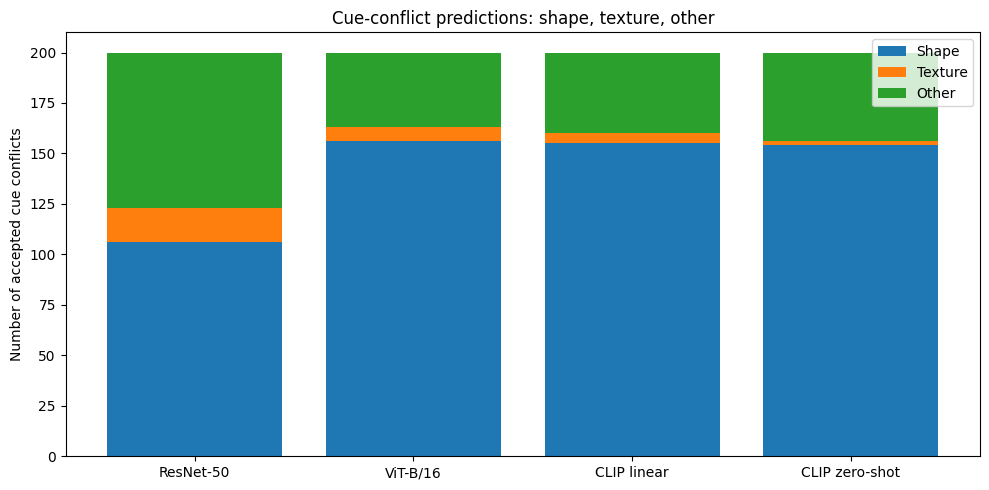

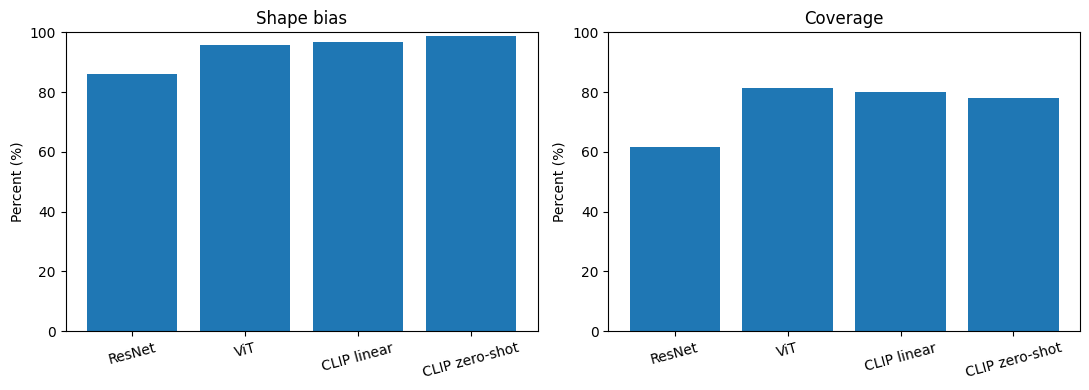

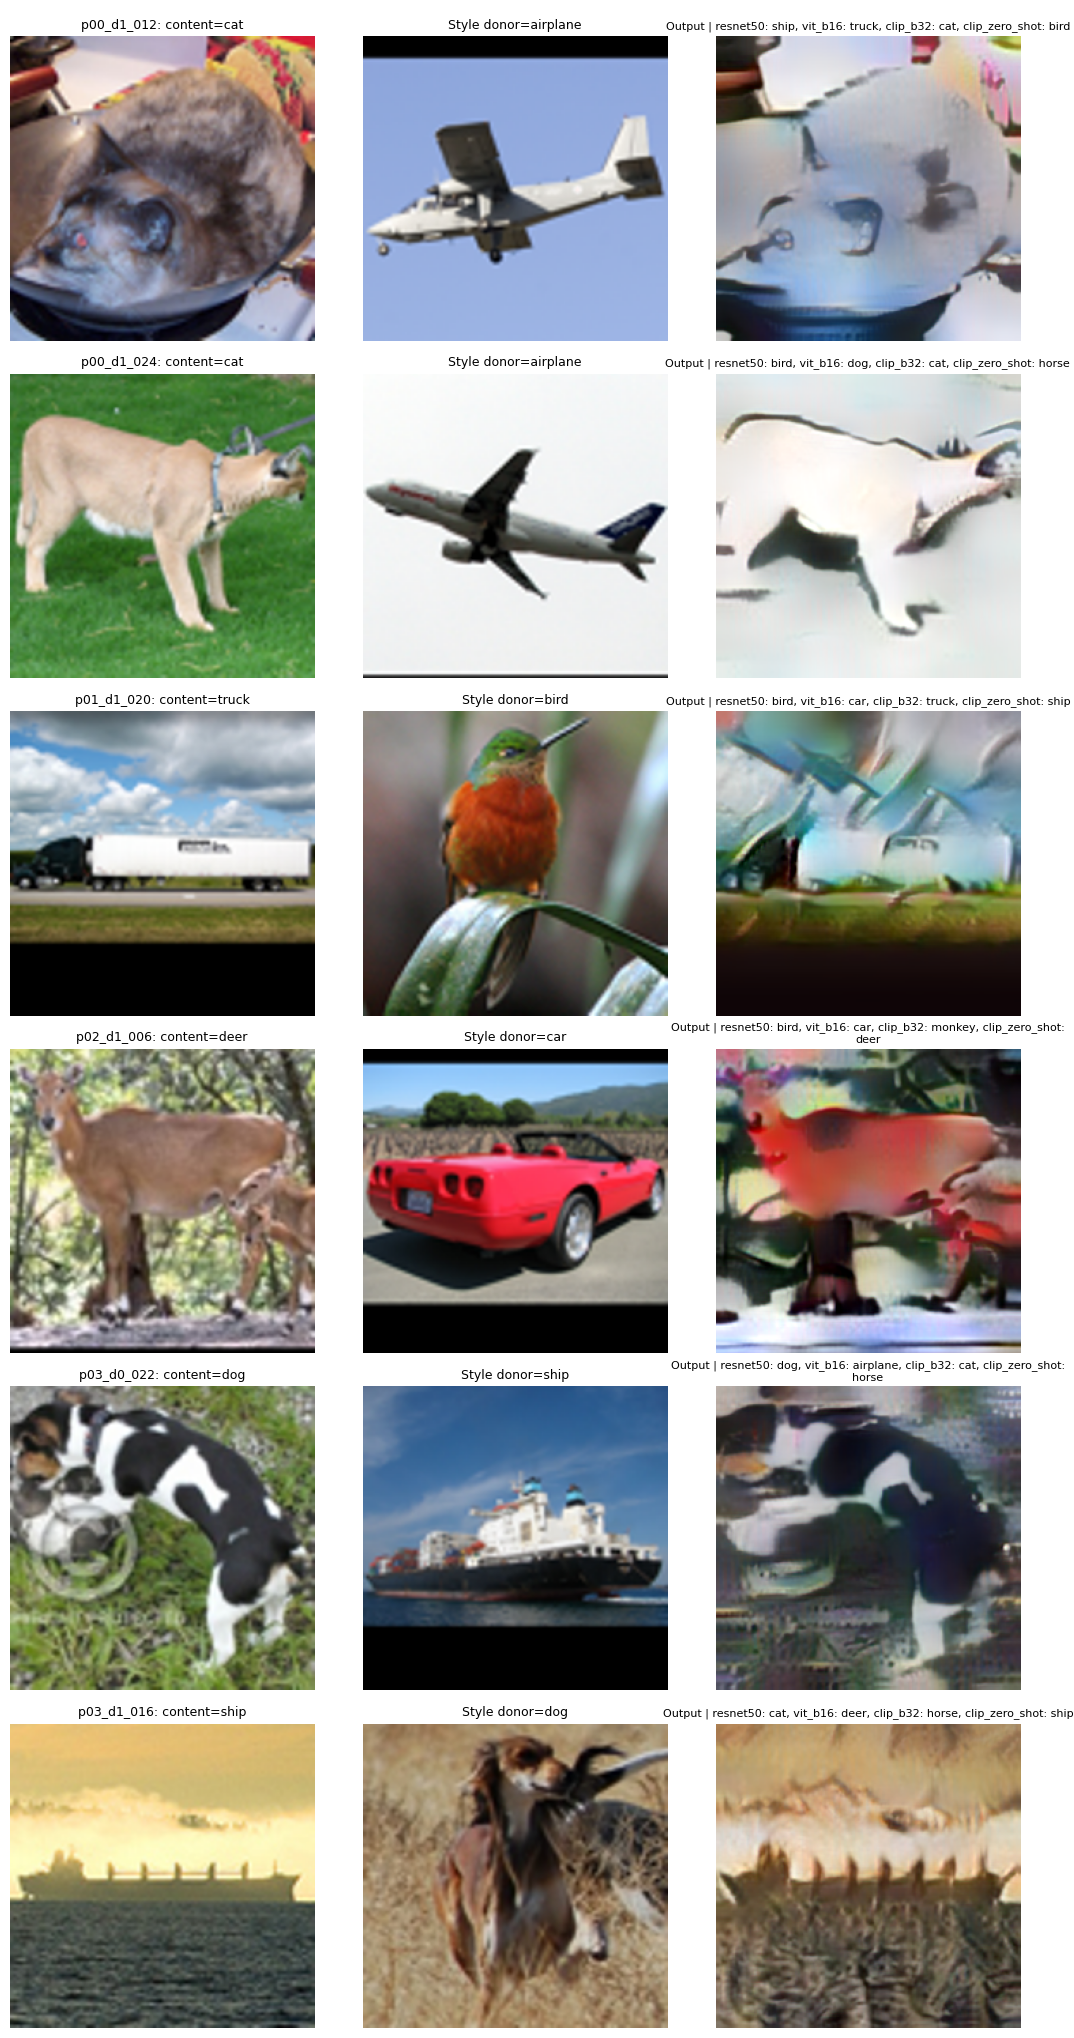

Figures and illustrative case metadata saved to: /content/drive/MyDrive/pa1-beyond-iid/task1/results/shape_texture


In [12]:
#! Figure 1: all three decision categories as counts
plot_df = summary_df.set_index("model").loc[MODEL_ORDER]
fig, ax = plt.subplots(figsize=(10, 5))
left = np.zeros(len(plot_df))
for column, label in (("n_shape", "Shape"), ("n_texture", "Texture"), ("n_other", "Other")):
    values = plot_df[column].to_numpy()
    ax.bar(np.arange(len(plot_df)), values, bottom=left, label=label)
    left += values
ax.set_xticks(np.arange(len(plot_df)), ["ResNet-50", "ViT-B/16", "CLIP linear", "CLIP zero-shot"])
ax.set_ylabel("Number of accepted cue conflicts")
ax.set_title("Cue-conflict predictions: shape, texture, other")
ax.legend()
fig.tight_layout()
fig.savefig(CUE_DIR / "cue_decision_counts.png", dpi=300, bbox_inches="tight")
plt.show()

#! Figure 2: report both bias and coverage, side by side
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, title in zip(axes, ("shape_bias_pct", "coverage_pct"), ("Shape bias", "Coverage")):
    ax.bar(np.arange(len(plot_df)), plot_df[metric].to_numpy())
    ax.set_xticks(np.arange(len(plot_df)), ["ResNet", "ViT", "CLIP linear", "CLIP zero-shot"], rotation=15)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Percent (%)")
    ax.set_title(title)
fig.tight_layout()
fig.savefig(CUE_DIR / "shape_bias_and_coverage.png", dpi=300, bbox_inches="tight")
plt.show()

#! Record model agreements and disagreements without changing the evaluation sample
wide = all_predictions.pivot(index="candidate_id", columns="model", values="prediction")
wide = wide.reindex(columns=MODEL_ORDER)
wide["number_distinct_predictions"] = wide[MODEL_ORDER].nunique(axis=1)
wide["any_other"] = all_predictions.groupby("candidate_id").decision.apply(
    lambda value: bool((value == "other").any())
)
wide = wide.sort_values(["number_distinct_predictions", "any_other"], ascending=False)
interesting_ids = wide.head(12).index.tolist()
cases = selected.set_index("candidate_id").loc[interesting_ids].reset_index()
for model_name in MODEL_ORDER:
    cases[f"{model_name}_prediction"] = wide.loc[interesting_ids, model_name].to_numpy()
    cases[f"{model_name}_class"] = [CLASS_NAMES[int(i)] for i in cases[f"{model_name}_prediction"]]
cases.to_csv(CUE_DIR / "illustrative_cases.csv", index=False)

#! Display a montage of six informative examples with model predictions
example_rows = cases.head(6)
fig, axes = plt.subplots(len(example_rows), 3, figsize=(11, len(example_rows) * 3.4), squeeze=False)
for row_number, case in enumerate(example_rows.itertuples(index=False)):
    ims = [canonical_image(case.content_pos), canonical_image(case.style_pos),
           Image.open(CUE_DIR / case.image_file).convert("RGB")]
    for column, image in enumerate(ims):
        axes[row_number, column].imshow(image)
        axes[row_number, column].axis("off")
    axes[row_number, 0].set_title(f"{case.candidate_id}: content={case.content_class}", fontsize=9)
    axes[row_number, 1].set_title(f"Style donor={case.style_class}", fontsize=9)
    verdicts = [f"{model}: {CLASS_NAMES[int(wide.loc[case.candidate_id, model])]}"
                for model in MODEL_ORDER]
    axes[row_number, 2].set_title("Output | " + ", ".join(verdicts), fontsize=8, wrap=True)
fig.tight_layout()
fig.savefig(CUE_DIR / "cue_conflict_examples.png", dpi=200, bbox_inches="tight")
plt.show()
print("Figures and illustrative case metadata saved to:", CUE_DIR)


## Cell 10 — Lightweight **read-only** final verification
Reload the saved review, selection, metrics, and four prediction archives from Drive. Require the minimum valid balanced sample and matching selected IDs, but avoid dozens of redundant assertions. This cell **never creates missing evidence**. Only disconnect the runtime after this succeeds.

In [13]:
#! Confirm saved review, balanced sample, and model results exist
required_files = [
    "experiment_config.json", "adain_source.json", "candidate_manifest.csv",
    "review_decisions.csv", "review_frozen.csv", "review_summary.json",
    "accept_reject_counts.csv", "selected_manifest.csv", "summary.csv", "summary.json",
    "predictions.csv", "per_pair_direction.csv", "cue_decision_counts.png",
    "shape_bias_and_coverage.png", "illustrative_cases.csv", "cue_conflict_examples.png"
]
required_files += [f"{model}_cue_predictions.npz" for model in MODEL_ORDER]
missing = [name for name in required_files if not (CUE_DIR / name).is_file()]
missing += [f"feature:{model}" for model in MODEL_NAMES
            if not (FEATURE_DIR / f"{model}_cue_conflict.pt").is_file()]
if missing:
    raise FileNotFoundError(f"Part E outputs missing: {missing}")

saved_selected = pd.read_csv(CUE_DIR / "selected_manifest.csv")
saved_summary = pd.read_csv(CUE_DIR / "summary.csv")
if len(saved_selected) < 200 or len(saved_summary) != 4:
    raise ValueError("At least 200 valid conflicts and four model results are required.")

expected_ids = saved_selected.candidate_id.to_numpy()
for model_name in MODEL_ORDER:
    with np.load(CUE_DIR / f"{model_name}_cue_predictions.npz", allow_pickle=False) as output:
        if (not np.array_equal(output["candidate_ids"], expected_ids)
            or len(output["y_pred"]) != len(saved_selected)):
            raise ValueError(f"Saved image ordering differs for {model_name}.")
    print("Verified:", model_name, len(saved_selected), "predictions")

print("\nPART E SAVED —", len(saved_selected), "valid balanced cue conflicts")
print("Review count details:", CUE_DIR / "accept_reject_counts.csv")
print("All output files:", CUE_DIR)
display(saved_summary.round(3))


Verified: resnet50 200 predictions
Verified: vit_b16 200 predictions
Verified: clip_b32 200 predictions
Verified: clip_zero_shot 200 predictions

PART E SAVED — 200 valid balanced cue conflicts
Review count details: /content/drive/MyDrive/pa1-beyond-iid/task1/results/shape_texture/accept_reject_counts.csv
All output files: /content/drive/MyDrive/pa1-beyond-iid/task1/results/shape_texture


,model,n_valid,n_shape,n_texture,n_other,shape_bias_pct,coverage_pct,content_accuracy,paired_clean_consistency,mean_max_confidence,seed
0,resnet50,200,106,17,77,86.179,61.5,0.530,0.54,0.712,6304
1,vit_b16,200,156,7,37,95.706,81.5,0.780,0.78,0.821,6304
2,clip_b32,200,155,5,40,96.875,80.0,0.775,0.77,0.170,6304
3,clip_zero_shot,200,154,2,44,98.718,78.0,0.770,0.78,0.747,6304
